In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [188]:
df = pd.read_csv(r"D:\downloads\consumer_electronics_sales_data.csv") 
df
######## Here I used this data to complete my project with it, where I find a data that suits objectives of the company and complete with in machine learning algorithms and EDA ######
######## And because its cleaned i have shown my skills in data cleaning using out source uncleaned data #######

,ProductID,ProductCategory,ProductBrand,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
0,5874,Smartphones,Other Brands,312.95,18,0,2,1,0
1,5875,Smart Watches,Samsung,980.39,35,1,7,2,1
2,5876,Tablets,Samsung,2606.72,63,0,1,5,1
3,5877,Smartphones,Samsung,870.40,63,1,10,3,1
4,5878,Tablets,Sony,1798.96,57,0,17,3,0
...,...,...,...,...,...,...,...,...,...
8995,14869,Smart Watches,Samsung,1041.15,36,1,16,4,0
8996,14870,Smartphones,Samsung,1485.69,57,0,5,1,1
8997,14871,Headphones,Samsung,2887.37,28,0,18,4,0
8998,14872,Tablets,HP,1490.45,38,0,4,2,1


In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductID             9000 non-null   int64  
 1   ProductCategory       9000 non-null   object 
 2   ProductBrand          9000 non-null   object 
 3   ProductPrice          9000 non-null   float64
 4   CustomerAge           9000 non-null   int64  
 5   CustomerGender        9000 non-null   int64  
 6   PurchaseFrequency     9000 non-null   int64  
 7   CustomerSatisfaction  9000 non-null   int64  
 8   PurchaseIntent        9000 non-null   int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 632.9+ KB


In [190]:
df.describe()

,ProductID,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
count,9000.00,9000.00,9000.00,9000.00,9000.00,9000.00,9000.00
mean,10373.50,1527.43,43.35,0.51,10.05,3.00,0.57
std,2598.22,829.90,15.06,0.50,5.46,1.41,0.50
min,5874.00,100.38,18.00,0.00,1.00,1.00,0.00
25%,8123.75,809.17,30.00,0.00,5.00,2.00,0.00
50%,10373.50,1513.02,43.00,1.00,10.00,3.00,1.00
75%,12623.25,2244.42,56.00,1.00,15.00,4.00,1.00
max,14873.00,2999.85,69.00,1.00,19.00,5.00,1.00


In [191]:
desc = df.describe()
desc.loc["count"] = desc.loc["count"].apply(lambda x: f"{int(x)}")
desc.columns.to_list()
desc = desc.drop('ProductID', axis=1)
desc

C:\Users\oasm2\AppData\Local\Temp\ipykernel_12144\1293875028.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9000' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  desc.loc["count"] = desc.loc["count"].apply(lambda x: f"{int(x)}")
C:\Users\oasm2\AppData\Local\Temp\ipykernel_12144\1293875028.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9000' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  desc.loc["count"] = desc.loc["count"].apply(lambda x: f"{int(x)}")
C:\Users\oasm2\AppData\Local\Temp\ipykernel_12144\1293875028.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9000' has dtype incompatible with float64, please explicitly cast to a compatible dt

,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
count,9000,9000,9000,9000,9000,9000
mean,1527.43,43.35,0.51,10.05,3.00,0.57
std,829.90,15.06,0.50,5.46,1.41,0.50
min,100.38,18.00,0.00,1.00,1.00,0.00
25%,809.17,30.00,0.00,5.00,2.00,0.00
50%,1513.02,43.00,1.00,10.00,3.00,1.00
75%,2244.42,56.00,1.00,15.00,4.00,1.00
max,2999.85,69.00,1.00,19.00,5.00,1.00


In [192]:
top500 = df.sort_values(by="CustomerSatisfaction", ascending=False).head(500)
top500["ProductBrand"].value_counts()
##From this type of analysis I have found that major customer satisfaction comes from buying "Sony" products which can see that it could be a minor proof that company could increase sellings## 

ProductBrand
Sony            106
Other Brands    103
HP               98
Apple            97
Samsung          96
Name: count, dtype: int64

In [193]:
df.corr(numeric_only= True).drop(index ="ProductID", columns= "ProductID")
## Note: Here we can see that there is no relation between (Consumer Satifaction) and (Product Price); (Product price) and (Customer Gender) ##


,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
ProductPrice,1.00,-0.01,0.00,0.01,0.00,-0.02
CustomerAge,-0.01,1.00,-0.01,0.01,0.00,0.29
CustomerGender,0.00,-0.01,1.00,-0.01,0.01,0.50
PurchaseFrequency,0.01,0.01,-0.01,1.00,0.02,-0.00
CustomerSatisfaction,0.00,0.00,0.01,0.02,1.00,0.39
PurchaseIntent,-0.02,0.29,0.50,-0.00,0.39,1.00


<function matplotlib.pyplot.show(close=None, block=None)>

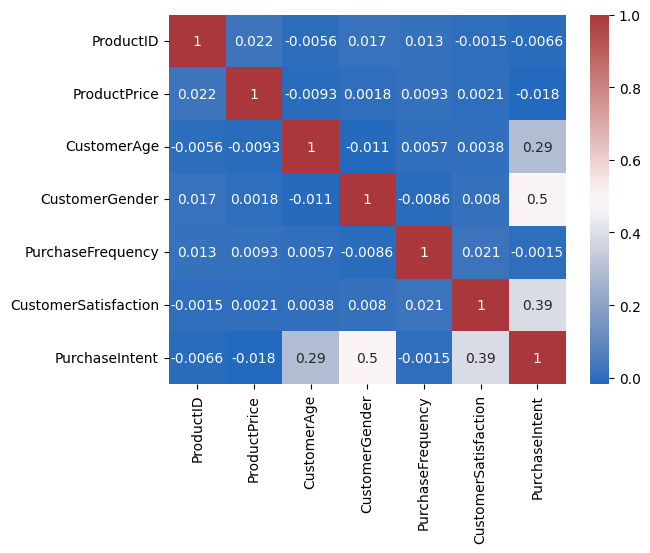

In [194]:
sns.heatmap(df.corr(numeric_only=True), annot= True, cmap="vlag")
plt.Figure(figsize=(7,8))
plt.show

In [195]:
without_ID_column = df.drop("ProductID", axis=1)
to_draw = without_ID_column.groupby('ProductCategory')['CustomerAge'].mean().sort_values(ascending=True)
### Here we see that the most Age who pruchase these products are early 40's means we can use our advertisments that fits fir this age ####

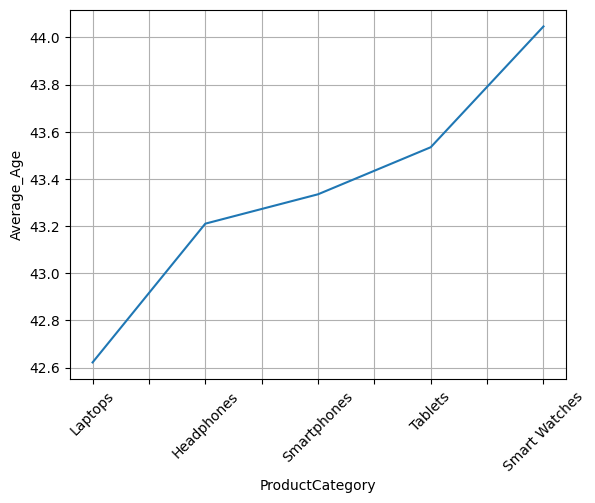

In [204]:
to_draw.plot()
plt.Figure(figsize=(30,4))
plt.xticks(rotation=45)
plt.ylabel("Average_Age")
plt.tight_layout
plt.grid()
plt.show()

In [197]:
to_draw2 = without_ID_column.groupby('ProductCategory').mean(numeric_only=True).sort_values(by="ProductCategory",ascending=True)
to_draw2

,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
ProductCategory,,,,,,
Headphones,1567.21,43.21,0.51,10.36,3.00,0.56
Laptops,1522.45,42.62,0.49,10.10,3.00,0.55
Smart Watches,1538.93,44.05,0.52,9.90,3.00,0.58
Smartphones,1479.30,43.33,0.51,9.99,3.00,0.58
Tablets,1531.85,43.53,0.51,9.94,2.99,0.56


(array([1, 2, 3, 4, 5]),
 [Text(1, 0, 'CustomerAge'),
  Text(2, 0, 'CustomerGender'),
  Text(3, 0, 'PurchaseFrequency'),
  Text(4, 0, 'CustomerSatisfaction'),
  Text(5, 0, 'PurchaseIntent')])

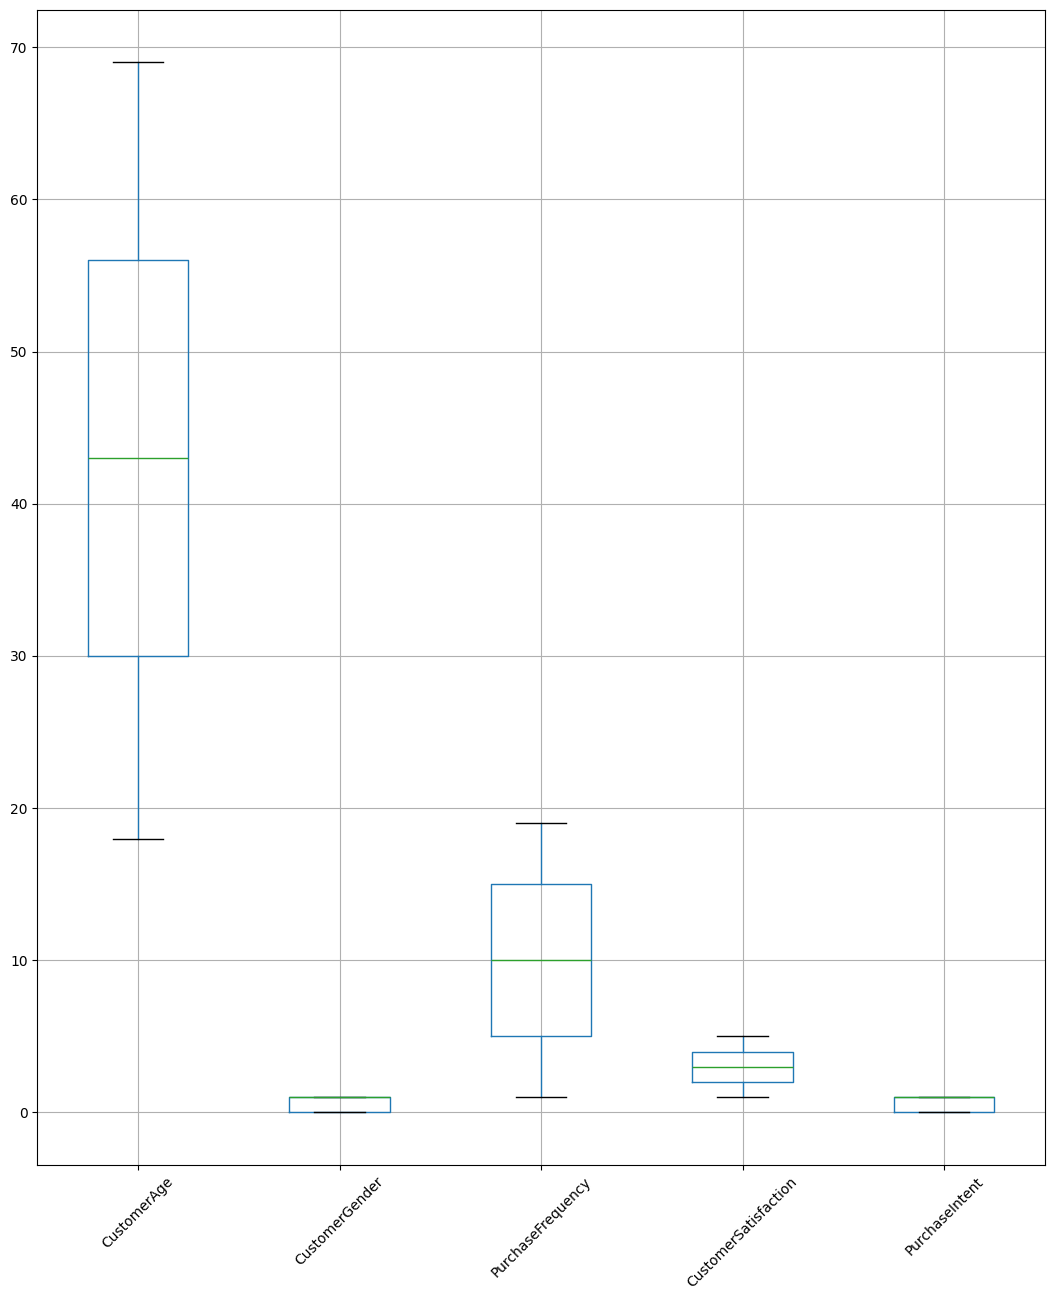

In [207]:
without_ID_column_and_price = without_ID_column.drop("ProductPrice", axis=1)
without_ID_column_and_price.boxplot(figsize=(13,15))
plt.xticks(rotation= 45)
##### Here we see that Product Price has outliers faraway from the 75th percentile and 25th Percentile or third and first quartile which tell us that price has prices faraway the range if we want to put them on box we have make it fiarly deal #####